In [1]:
# Stage 1: Import Libraries
# Importing libraries for text processing, machine learning, and evaluation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Stage 2: Load Dataset
# Loading the IMDB movie review dataset.

In [4]:
df = pd.read_csv("IMDB_Dataset.csv")

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
# Stage 3: Data Understanding
# Checking the distribution of positive and negative reviews.

In [9]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

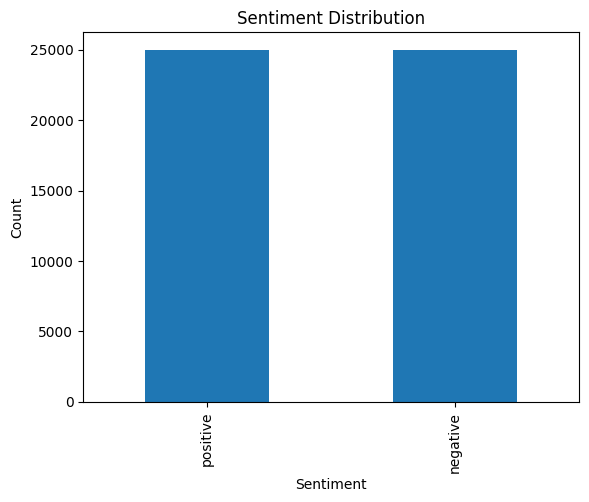

In [10]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [11]:
# Stage 4: Data Cleaning
# Checking for missing values and duplicate reviews.

In [12]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(418)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
# Stage 5: Convert Target Variable
# Converting positive and negative labels into numerical values.
# Machine learning models work with numbers.

In [16]:
df['sentiment'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [17]:
# Stage 6: Text Vectorization
# Converting text reviews into numerical features using TF-IDF.
# Machine learning models cannot understand raw text.

In [18]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(
    df['review']
)

y = df['sentiment']

In [19]:
# Stage 7: Train-Test Split
# Splitting the dataset into training and testing sets.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Stage 8: Logistic Regression

In [22]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

print("Accuracy:", accuracy_lr)

Accuracy: 0.8852475547040436


In [23]:
# Stage 9: Naive Bayes Classifier

In [24]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

accuracy_nb = accuracy_score(
    y_test,
    pred_nb
)

print("Accuracy:", accuracy_nb)

Accuracy: 0.850257134213976


In [25]:
# Stage 10: KNN Classifier

In [26]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(
    y_test,
    pred_knn
)

print("Accuracy:", accuracy_knn)

Accuracy: 0.7217908641726328


In [27]:
# Stage 11: Decision Tree Classifier

In [28]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    pred_dt
)

print("Accuracy:", accuracy_dt)

Accuracy: 0.7151356256932541


In [29]:
# Stage 12: Random Forest Classifier

In [30]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print("Accuracy:", accuracy_rf)

Accuracy: 0.840375113441565


In [31]:
# Stage 13: XGBoost Classifier

In [32]:
xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

accuracy_xgb = accuracy_score(
    y_test,
    pred_xgb
)

print("Accuracy:", accuracy_xgb)

Accuracy: 0.8522738731471211


In [33]:
# Stage 14: Model Comparison

In [34]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Naive Bayes',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy':[
        accuracy_lr,
        accuracy_nb,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.885248
1,Naive Bayes,0.850257
2,KNN,0.721791
3,Decision Tree,0.715136
4,Random Forest,0.840375
5,XGBoost,0.852274


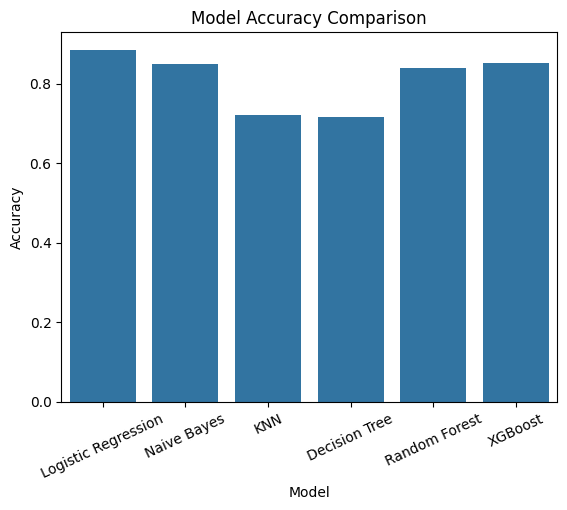

In [35]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=25)

plt.title("Model Accuracy Comparison")

plt.show()

In [36]:
# Stage 15: Best Model Evaluation
# Use whichever model gets the highest accuracy.

In [37]:
print(
    confusion_matrix(
        y_test,
        pred_lr
    )
)

[[4300  639]
 [ 499 4479]]


In [38]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4939
           1       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [39]:
df['sentiment'].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

In [40]:
# Final Findings
# 1. The dataset contained 49,582 movie reviews, including 24,884 positive reviews and 24,698 negative reviews.
# 2. Logistic Regression achieved the highest accuracy of 88.52%, making it the best-performing model in this analysis.
# 3. Naive Bayes achieved an accuracy of 85.03%, showing good performance for text classification tasks.
# 4. XGBoost achieved an accuracy of 85.23%, performing similarly to Naive Bayes.
# 5. Random Forest achieved an accuracy of 84.04%.
# 6. K-Nearest Neighbors (KNN) and Decision Tree achieved accuracies of 72.18% and 71.51% respectively, which were lower than the other models.
# 7. The confusion matrix showed that Logistic Regression correctly classified most positive and negative reviews, with relatively few misclassifications.
# 8. The classification report showed balanced precision, recall, and F1-scores for both sentiment classes, indicating reliable sentiment prediction performance.

In [41]:
# Conclusion
# Performed sentiment analysis on IMDB movie reviews using multiple machine learning algorithms.
# Applied TF-IDF Vectorization to convert review text into numerical features for model training.
# Compared the performance of Logistic Regression, Naive Bayes, KNN, Decision Tree, Random Forest, and XGBoost.
# Logistic Regression achieved the highest accuracy of 88.52%, making it the best-performing model.
# The model successfully classified both positive and negative reviews with high precision and recall.
# This project demonstrated the effectiveness of machine learning and NLP techniques for automated sentiment classification.